In [3]:
from chembl_webresource_client.new_client import new_client
import pandas as pd
from tqdm import tqdm

# 开始获取数据
activity = new_client.activity
data_iter = activity.filter(
    target_chembl_id="CHEMBL5557",
    standard_type="IC50",
    standard_units="nM",
    confidence_score__gte=9
)

# 带进度条下载
print("开始下载数据...")
data_list = []
for item in tqdm(data_iter, desc="下载进度"):
    data_list.append(item)

# 保存为CSV
df = pd.DataFrame(data_list)
df.to_csv("hERG_IC50_data.csv", index=False)

print(f"\n下载完成！共 {len(df)} 条数据")
print("文件已保存：hERG_IC50_data.csv")

开始下载数据...


下载进度: 100%|████████████████████████████████████████████████████████████████████████| 22/22 [00:02<00:00, 10.24it/s]


下载完成！共 22 条数据
文件已保存：hERG_IC50_data.csv


In [ ]:
CHEMBL240

In [4]:
from chembl_webresource_client.new_client import new_client
import pandas as pd
from tqdm import tqdm

# 开始获取数据
activity = new_client.activity
data_iter = activity.filter(
    target_chembl_id="CHEMBL240",
    standard_type="IC50",
    standard_units="nM",
    confidence_score__gte=9
)

# 带进度条下载
print("开始下载数据...")
data_list = []
for item in tqdm(data_iter, desc="下载进度"):
    data_list.append(item)

# 保存为CSV
df = pd.DataFrame(data_list)
df.to_csv("hERG_IC50_data.csv", index=False)

print(f"\n下载完成！共 {len(df)} 条数据")
print("文件已保存：hERG_IC50_data.csv")

开始下载数据...


下载进度: 100%|██████████████████████████████████████████████████████████████████| 16627/16627 [23:39<00:00, 11.71it/s]



下载完成！共 16627 条数据
文件已保存：hERG_IC50_data.csv


In [5]:
import pandas as pd
import numpy as np
from tqdm import tqdm  # 进度条工具

# ==============================================
# 1. 读取数据（显示进度）
# ==============================================
print("正在读取数据...")
df = pd.read_csv("hERG_IC50_data.csv")
print(f"读取完成，原始数据共 {len(df)} 条\n")

# ==============================================
# 2. 保留需要的列
# ==============================================
print("正在筛选需要的列...")
use_cols = ['molecule_chembl_id', 'canonical_smiles', 'standard_value', 'standard_units']
df = df[use_cols]
tqdm.pandas(desc="筛选列")
print("列筛选完成 ✅\n")

# ==============================================
# 3. 重命名列（简单好记）
# ==============================================
print("正在重命名列...")
df.columns = ['chembl_id', 'smiles', 'ic50', 'units']
print("重命名完成 ✅\n")

# ==============================================
# 4. 删除空值（带进度）
# ==============================================
print("正在删除空值行...")
df = df.dropna()
tqdm.pandas(desc="删除空值")
print(f"删除后剩余 {len(df)} 条 ✅\n")

# ==============================================
# 5. 删除 IC50 <= 0 的异常值
# ==============================================
print("正在移除异常值（ic50>0）...")
df = df[df['ic50'] > 0]
tqdm.pandas(desc="移除异常值")
print(f"移除后剩余 {len(df)} 条 ✅\n")

# ==============================================
# 6. 去重（同一个SMILES只留一条）
# ==============================================
print("正在对化合物去重...")
df = df.drop_duplicates(subset=['smiles'])
tqdm.pandas(desc="去重中")
print(f"去重后剩余 {len(df)} 条 ✅\n")

# ==============================================
# 7. 只保留单位为 nM 的数据
# ==============================================
print("正在筛选单位为 nM 的数据...")
df = df[df['units'] == 'nM']
tqdm.pdesc="筛选单位 nM"
print(f"筛选后剩余 {len(df)} 条 ✅\n")

# ==============================================
# 8. 计算 pIC50（建模必须用！）
# ==============================================
print("正在计算 pIC50...")
df['pIC50'] = -np.log10(df['ic50'] * 1e-9)
tqdm.pdesc="计算pIC50"
print("pIC50 计算完成 ✅\n")

# ==============================================
# 9. 过滤合理的 pIC50 范围（3~10）
# ==============================================
print("正在过滤合理的 pIC50 范围（3~10）...")
df = df[(df['pIC50'] > 3) & (df['pIC50'] < 10)]
tqdm.pdesc="过滤pIC50范围"
print(f"过滤后剩余 {len(df)} 条 ✅\n")

# ==============================================
# 10. 重置行号
# ==============================================
print("正在重置索引...")
df = df.reset_index(drop=True)
print("索引重置完成 ✅\n")

# ==============================================
# 11. 保存最终清洗好的数据
# ==============================================
print("正在保存文件...")
df.to_csv("hERG_clean_data.csv", index=False)

# ==============================================
# 最终结果
# ==============================================
print("\n==========================================")
print(f"✅ 数据清洗全部完成！")
print(f"📊 最终可用数据：{len(df)} 条")
print(f"📁 已保存为：hERG_clean_data.csv")
print("==========================================")

正在读取数据...
读取完成，原始数据共 16627 条

正在筛选需要的列...
列筛选完成 ✅

正在重命名列...
重命名完成 ✅

正在删除空值行...
删除后剩余 16624 条 ✅

正在移除异常值（ic50>0）...
移除后剩余 16624 条 ✅

正在对化合物去重...
去重后剩余 13800 条 ✅

正在筛选单位为 nM 的数据...
筛选后剩余 13800 条 ✅

正在计算 pIC50...
pIC50 计算完成 ✅

正在过滤合理的 pIC50 范围（3~10）...
过滤后剩余 13734 条 ✅

正在重置索引...
索引重置完成 ✅

正在保存文件...

✅ 数据清洗全部完成！
📊 最终可用数据：13734 条
📁 已保存为：hERG_clean_data.csv


C:\Users\lixinrong\AppData\Local\Temp\ipykernel_13772\79031689.py:9: DtypeWarning: Columns (0,1,7,8,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("hERG_IC50_data.csv")


原始数据量： 13734
生成增强指纹...


生成指纹: 100%|█████████████████████████████████████████████████████████████████| 13734/13734 [00:39<00:00, 344.64it/s]


有效数据量：13734
最终数据量（含重复）：13734
特征维度：(13734, 1197)
交叉验证 R²: 0.5825 (±0.0191)

测试集 R² = 0.6128
测试集 RMSE = 0.5539


D:\Downloads\anaconda\envs\pytorch_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Downloads\anaconda\envs\pytorch_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Downloads\anaconda\envs\pytorch_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Downloads\anaconda\envs\pytorch_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


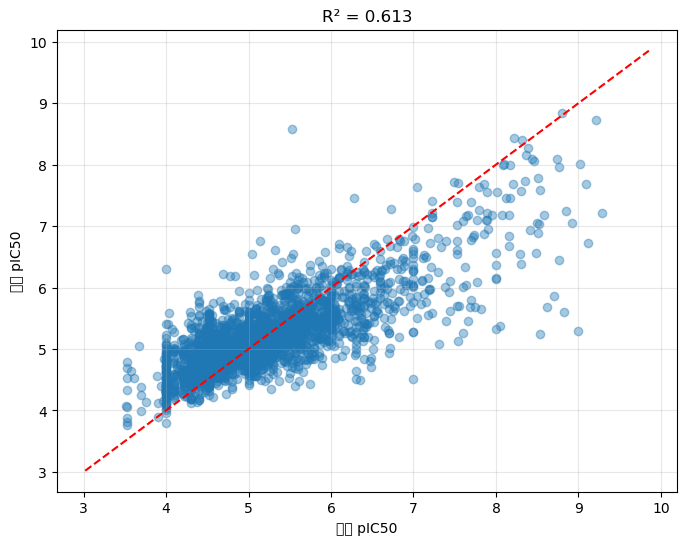


特征重要性非零数：1149/1197


In [2]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys, Descriptors

# 读取数据
df = pd.read_csv("hERG_clean_data.csv")
print("原始数据量：", len(df))

# 增强的指纹生成
def smiles_to_enhanced_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    # 三种特征融合
    morgan = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
    maccs = MACCSkeys.GenMACCSKeys(mol)
    
    # 关键分子属性
    try:
        props = np.array([
            Descriptors.MolWt(mol),
            Descriptors.NumRotatableBonds(mol),
            Descriptors.NumHDonors(mol),
            Descriptors.NumHAcceptors(mol),
            Descriptors.TPSA(mol),
            Descriptors.MolLogP(mol),
        ])
        # 处理异常值
        props = np.nan_to_num(props, nan=0.0, posinf=0.0, neginf=0.0)
    except:
        props = np.zeros(6)
    
    return np.concatenate([morgan, maccs, props])

# 生成指纹
print("生成增强指纹...")
fps = []
for s in tqdm(df['smiles'], desc="生成指纹"):
    fps.append(smiles_to_enhanced_fp(s))

df['fp'] = fps
df = df.dropna(subset=['fp'])
print(f"有效数据量：{len(df)}")

# 关键：不要取平均，保留所有数据
print(f"最终数据量（含重复）：{len(df)}")

# 准备数据
X = np.array(df['fp'].tolist())
y = df['pIC50'].values
print(f"特征维度：{X.shape}")

# 划分数据
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 优化模型
model = XGBRegressor(
    n_estimators=1500,
    max_depth=5,
    learning_rate=0.015,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=4,
    reg_alpha=0.3,
    reg_lambda=1.5,
    gamma=0.3,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

# 交叉验证
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
print(f"交叉验证 R²: {scores.mean():.4f} (±{scores.std():.4f})")

# 训练
model.fit(X_train, y_train)

# 预测
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n测试集 R² = {r2:.4f}")
print(f"测试集 RMSE = {rmse:.4f}")

# 可视化
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("真实 pIC50")
plt.ylabel("预测 pIC50")
plt.title(f"R² = {r2:.3f}")
plt.grid(True, alpha=0.3)
plt.show()

# 特征重要性
importance = model.feature_importances_
print(f"\n特征重要性非零数：{np.sum(importance > 0)}/{len(importance)}")

In [3]:
# 导入保存模型的工具
import joblib

# 保存你训练好的 XGBoost 模型
joblib.dump(model, "hERG_XGBoost_model.pkl")

# 提示保存成功
print("✅ 模型已保存成功！文件名为：hERG_XGBoost_model.pkl")

✅ 模型已保存成功！文件名为：hERG_XGBoost_model.pkl


In [7]:
import numpy as np
import joblib
from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys, Descriptors

# ======================
# 1. 加载训练好的模型
# ======================
model = joblib.load("hERG_XGBoost_model.pkl")  # 加载你保存的模型
print("✅ 模型加载成功！")

# ======================
# 2. 定义和训练时完全一样的特征函数（必须一模一样！）
# ======================
def smiles_to_enhanced_fp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    # 三种特征融合（和训练时完全相同）
    morgan = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
    maccs = MACCSkeys.GenMACCSKeys(mol)
    
    # 6个理化属性
    try:
        props = np.array([
            Descriptors.MolWt(mol),
            Descriptors.NumRotatableBonds(mol),
            Descriptors.NumHDonors(mol),
            Descriptors.NumHAcceptors(mol),
            Descriptors.TPSA(mol),
            Descriptors.MolLogP(mol),
        ])
        props = np.nan_to_num(props, nan=0.0, posinf=0.0, neginf=0.0)
    except:
        props = np.zeros(6)
    
    return np.concatenate([morgan, maccs, props])

# ======================
# 3. 在这里输入【你自己的化合物 SMILES】
# ======================
# 示例，你可以替换成你自己的！
my_smiles = "OC(=O)[C@H]1C2CCC(CC2)[C@@H]1Nc1nc(ncc1F)-c1c[nH]c2ncc(F)cc12"  # 自己改这里！

# 生成特征
fp = smiles_to_enhanced_fp(my_smiles)
if fp is None:
    print("❌ SMILES 格式错误！")
else:
    X_new = fp.reshape(1, -1)  # 变成模型需要的形状
    
    # ======================
    # 4. 预测 pIC50
    # ======================
    pred_pIC50 = model.predict(X_new)[0]
    
    print("\n🧪 预测完成！")
    print(f"SMILES: {my_smiles}")
    print(f"预测 pIC50 = {pred_pIC50:.3f}")

    # ======================
    # 毒性判断（hERG 标准）
    # ======================
    print("\n⚕️ hERG 毒性判断：")
    if pred_pIC50 >= 7.0:
        print("🟥 强 hERG 抑制（毒性高）")
    elif pred_pIC50 >= 6.0:
        print("🟧 中等 hERG 抑制")
    elif pred_pIC50 >= 5.0:
        print("🟨 弱抑制")
    else:
        print("🟩 基本无抑制（安全）")

✅ 模型加载成功！

🧪 预测完成！
SMILES: OC(=O)[C@H]1C2CCC(CC2)[C@@H]1Nc1nc(ncc1F)-c1c[nH]c2ncc(F)cc12
预测 pIC50 = 4.466

⚕️ hERG 毒性判断：
🟩 基本无抑制（安全）
